In [7]:
import cv2
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import kagglehub

In [8]:
path = kagglehub.dataset_download("oneoneliu/cornell-grasp")

# glob to recursively find all files ending in 'r.png' raw images
# the sorted() function makes sure images and their text files are correct
image_paths = sorted(glob.glob(os.path.join(path, "**/*r.png"), recursive=True))
print(f"Total images found: {len(image_paths)}")

Using Colab cache for faster access to the 'cornell-grasp' dataset.
Total images found: 896


In [13]:
# the robot needs to know where it can (positive) and can't (negative) grasp. these are stored as four coordinate pairs.
def load_rectangles(rect_file):
    rects = []
    if not os.path.exists(rect_file): return rects
    coords = []
    with open(rect_file, "r") as f:
        for line in f:
            # files use semicolons/spaces, so we default to spaces to split easier
            line = line.replace(";", " ").strip()
            parts = line.split()
            if len(parts) >= 2:
                try:
                    val_x = float(parts[0])
                    val_y = float(parts[1])
                    if not np.isnan(val_x) and not np.isnan(val_y):
                        coords.append([val_x, val_y])
                except ValueError:
                    continue
    # every four points define one rectangle
    # we convert them to integers because pixel coordinates must be whole numbers
    for i in range(0, len(coords), 4):
      points = coords[i:i+4]
      # only try to convert to integer if there are four points
      if len(points) == 4:
          try:
              rect = np.array(points, dtype=np.int32)
              rects.append(rect)
          except ValueError:
              continue
    return rects

# a point cloud is just a list of points in 3D space so to use it with a 2D image, we make it so it maps each 3D point to a specific 2D pixel index.
def create_depth_image(pcd_file, shape):
    h, w = shape[:2]
    # initialize this empty image to hold depth values
    depth_img = np.zeros((h, w), dtype=np.float32)
    with open(pcd_file, 'r') as f:
        for line in f:
            parts = line.split()
            # following the Cornell format (column 2 for Z/depth and column 4 for the pixel index)
            if len(parts) != 5: continue
            try:
                z = float(parts[2]) # how far is object from camera
                idx = int(parts[4]) # which pixel this depth belongs to
                # convert this to grid coordinations
                row, col = idx // w, idx % w
                if row < h and col < w:
                    depth_img[row, col] = z
            except ValueError: continue
    return depth_img

# the robot focuses only on the object.
# we extract the 'patch' inside the rectangle and convert it to YUV/Depth because it highlights the shape and texture better than raw RGB.
def extract_patch_features(rgbd_image, rect):
    # the masks makes it so we only look at the pixels inside the tilted rectangle.
    mask = np.zeros(rgbd_image.shape[:2], dtype=np.uint8)
    cv2.fillPoly(mask, [rect], 255)
    x, y, w, h = cv2.boundingRect(rect)
    img_h, img_w = rgbd_image.shape[:2]
    x1, y1, x2, y2 = max(0, x), max(0, y), min(img_w, x + w), min(img_h, y + h)

    # crop rgbd image
    patch = rgbd_image[y1:y2, x1:x2]
    patch_mask = mask[y1:y2, x1:x2]
    if patch.size == 0: return None, None

    # black out everything that isnt inside tilted rect
    masked_patch = cv2.bitwise_and(patch, patch, mask=patch_mask)

    # Y is brightness, UV is color. best to convert from rgb to yuv because it is better in cases like changes in lighting
    rgb_part = masked_patch[:, :, :3].astype(np.uint8)
    yuv_patch = cv2.cvtColor(rgb_part, cv2.COLOR_RGB2YUV)
    # the robot needs to know depth to know how wide to open gripper
    depth_patch = patch[:, :, 3]
    return yuv_patch, depth_patch

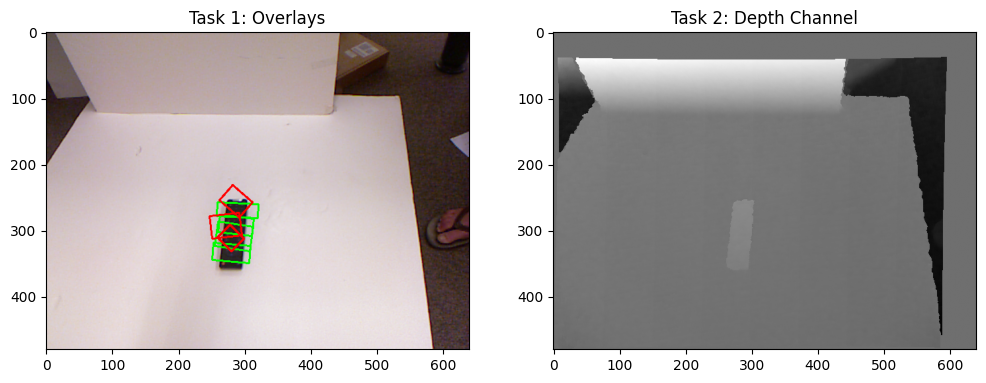

In [14]:
# test on the first image
test_img_path = image_paths[0]
base = test_img_path[:-5]

# load raw image and convert from bgr (which is default) -> rgb
img_bgr = cv2.imread(test_img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
pos_rects = load_rectangles(base + "cpos.txt")
neg_rects = load_rectangles(base + "cneg.txt")
depth_map = create_depth_image(base + ".txt", img_rgb.shape)

# load and draw rectangles where green = grab and red = dont grab
overlay = img_rgb.copy()
cv2.polylines(overlay, pos_rects, True, (0, 255, 0), 2)
cv2.polylines(overlay, neg_rects, True, (255, 0, 0), 2)

# create the 4th channel (depth) and stack it with rgb
rgbd = np.dstack((img_rgb, depth_map))

# results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.title("Task 1: Overlays")
plt.imshow(overlay)
plt.subplot(1, 2, 2)
plt.title("Task 2: Depth Channel")
plt.imshow(depth_map, cmap='gray')
plt.show()

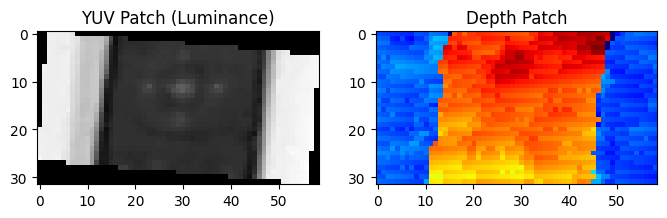

Number of feature patches extracted from this image: 4


In [15]:
all_features = []

# process positive rectangles for test image
for rect in pos_rects:
    yuv, depth_p = extract_patch_features(rgbd, rect)
    if yuv is not None:
        all_features.append((yuv, depth_p))

# show first patch
if all_features:
    sample_yuv, sample_depth = all_features[0]
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.title("YUV Patch (Luminance)")
    plt.imshow(sample_yuv[:,:,0], cmap='gray') # Showing 'Y' channel
    plt.subplot(1, 2, 2)
    plt.title("Depth Patch")
    plt.imshow(sample_depth, cmap='jet')
    plt.show()

print(f"Number of feature patches extracted from this image: {len(all_features)}")

In [16]:
# loop runs the logic over the entire dataset to prepare it for a model
final_dataset = []

for img_path in image_paths:
    base = img_path[:-5]
    if not os.path.exists(base + "cpos.txt") or not os.path.exists(base + ".txt"):
        continue

    # standerdize image and depth data
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    depth_map = create_depth_image(base + ".txt", img_rgb.shape)
    rgbd_combined = np.dstack((img_rgb, depth_map))

    # extract YUV + depth for the postive grasps
    pos_rects = load_rectangles(base + "cpos.txt")
    for rect in pos_rects:
        yuv, d = extract_patch_features(rgbd_combined, rect)
        if yuv is not None:
            final_dataset.append((yuv, d))